In [327]:
import pandas as pd
import matplotlib.pyplot as plt

In [328]:
df=pd.read_csv("E:/SC_DS_I/SC_DS_I/titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34,0,0,330911,8,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47,1,0,363272,7,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62,0,0,240276,10,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27,0,0,315154,9,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22,1,1,3101298,12,NaN,S


In [329]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    str    
 4   Sex          418 non-null    str    
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    str    
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     str    
 11  Embarked     418 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 39.3 KB


In [330]:
df["Ticket"] = pd.to_numeric(df["Ticket"], errors="coerce")
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    str    
 4   Sex          418 non-null    str    
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       296 non-null    float64
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     str    
 11  Embarked     418 non-null    str    
dtypes: float64(3), int64(5), str(4)
memory usage: 39.3 KB


In [331]:
df=df.drop(columns=["PassengerId","Name","Fare","Embarked"])
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Cabin
0,0,3,male,34,0,0,330911,NaN
1,1,3,female,47,1,0,363272,NaN
2,0,2,male,62,0,0,240276,NaN
3,0,3,male,27,0,0,315154,NaN
4,1,3,female,22,1,1,3101298,NaN


In [332]:
df["Sex"].value_counts()
df.isnull().sum()


Survived      0
Pclass        0
Sex           0
Age          86
SibSp         0
Parch         0
Ticket      122
Cabin       327
dtype: int64

In [333]:
df.drop(columns=["Cabin"],inplace=True)
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age          86
SibSp         0
Parch         0
Ticket      122
dtype: int64

In [334]:
df["Age"] = df["Age"].fillna(df["Age"].mean())
df["Ticket"] = df["Ticket"].fillna(df["Ticket"].mean())

df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
dtype: int64

In [335]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket
0,0,3,male,34,0,0,330911
1,1,3,female,47,1,0,363272
2,0,2,male,62,0,0,240276
3,0,3,male,27,0,0,315154
4,1,3,female,22,1,1,3101298


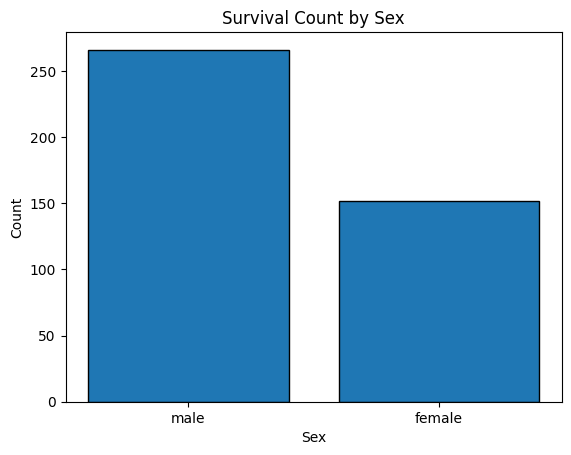

In [336]:
plt.bar(df["Sex"].unique(),df["Survived"].value_counts(),edgecolor="black")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.title("Survival Count by Sex")

plt.show()

Male survived more than female

In [337]:
def fun(x):
    if x>=df["Ticket"].mean():
        return "1"
    else:
        return "0"

df["rich"]=df["Ticket"].apply(fun)
pd.set_option("display.float_format", "{:.0f}".format)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,rich
0,0,3,male,34,0,0,330911,1
1,1,3,female,47,1,0,363272,1
2,0,2,male,62,0,0,240276,1
3,0,3,male,27,0,0,315154,1
4,1,3,female,22,1,1,3101298,1


Text(0.5, 1.0, 'Distribution of Rich and Poor Passengers')

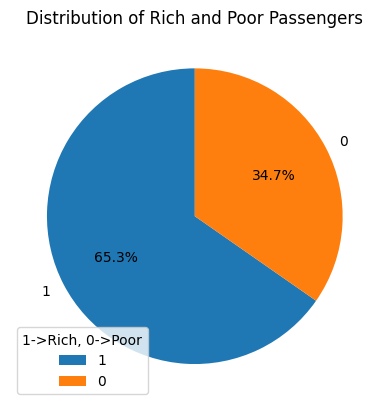

In [338]:
plt.pie(df["rich"].value_counts(),labels=df["rich"].unique(),autopct="%1.1f%%",startangle=90)
plt.legend(title="1->Rich, 0->Poor")
plt.title("Distribution of Rich and Poor Passengers")

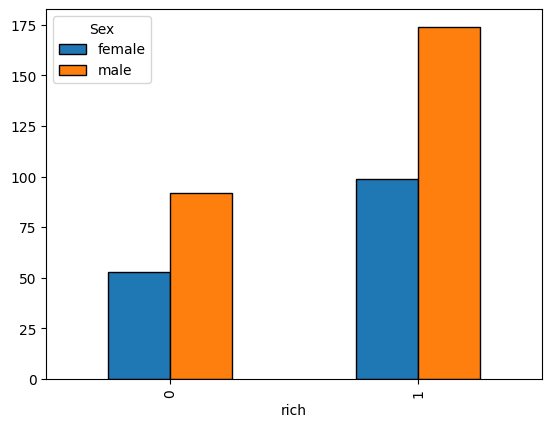

In [339]:
df.groupby(["rich", "Sex"]).size().unstack().plot(kind="bar", edgecolor="black")
plt.show()


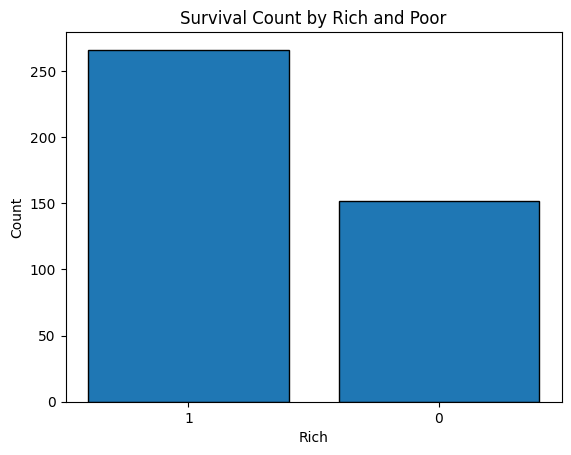

In [340]:
plt.bar(df["rich"].unique(),df["Survived"].value_counts(),edgecolor="black")
plt.xlabel("Rich")
plt.ylabel("Count")
plt.title("Survival Count by Rich and Poor")
plt.show()